Points:
[[2 3]
 [5 8]
 [1 2]
 [6 9]
 [7 7]]
Initial Centroids:
[[2 3]
 [6 9]]
Cluster Assignments:
[np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(1)]


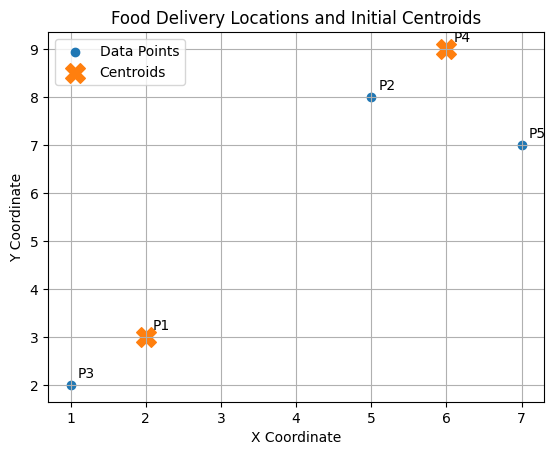

In [1]:
import numpy as np
import matplotlib.pyplot as plt

points = np.array([
    [2, 3],
    [5, 8],
    [1, 2],
    [6, 9],
    [7, 7]
])

centroids = np.array([
    [2, 3],
    [6, 9]
])

assignments = []

for point in points:
    distances = np.sqrt(np.sum((centroids - point) ** 2, axis=1))
    cluster = np.argmin(distances)
    assignments.append(cluster)

print("Points:")
print(points)

print("Initial Centroids:")
print(centroids)

print("Cluster Assignments:")
print(assignments)

plt.scatter(points[:, 0], points[:, 1], label="Data Points")
plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    marker="X",
    s=200,
    label="Centroids"
)

for i, point in enumerate(points):
    plt.annotate(
        f"P{i+1}",
        (point[0], point[1]),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.title("Food Delivery Locations and Initial Centroids")
plt.legend()
plt.grid()
plt.show()

In [2]:
import numpy as np

def assign_clusters(points, centroids):
    assignments = []

    for point in points:
        distances = np.sqrt(np.sum((centroids - point) ** 2, axis=1))
        cluster = np.argmin(distances)
        assignments.append(cluster)

    return assignments

points = np.array([
    [2, 3],
    [5, 8],
    [1, 2],
    [6, 9],
    [7, 7]
])

centroids = np.array([
    [2, 3],
    [6, 9]
])

assignments = assign_clusters(points, centroids)

print("Cluster Assignments:")
print(assignments)

Cluster Assignments:
[np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(1)]


In [ ]:
import numpy as np

def assign_clusters(points, centroids, distance_metric="euclidean"):
    assignments = []

    for point in points:
        if distance_metric == "euclidean":
            distances = np.sqrt(np.sum((centroids - point) ** 2, axis=1))
        elif distance_metric == "manhattan":
            distances = np.sum(np.abs(centroids - point), axis=1)
        else:
            raise ValueError("Distance metric must be 'euclidean' or 'manhattan'")

        cluster = np.argmin(distances)
        assignments.append(cluster)

    return assignments

points = np.array([
    [2, 3],
    [5, 8],
    [1, 2],
    [6, 9],
    [7, 7]
])

centroids = np.array([
    [2, 3],
    [6, 9]
])

metric = input("Enter distance metric (euclidean/manhattan): ").lower()

assignments = assign_clusters(
    points,
    centroids,
    metric
)

print("Distance Metric:", metric)
print("Cluster Assignments:", assignments)

In [4]:
import numpy as np

def update_centroids(points, assignments, k):
    new_centroids = []

    for cluster in range(k):
        cluster_points = points[np.array(assignments) == cluster]

        if len(cluster_points) > 0:
            centroid = np.mean(cluster_points, axis=0)
        else:
            centroid = np.zeros(points.shape[1])

        new_centroids.append(centroid)

    return np.array(new_centroids)

points = np.array([
    [2, 3],
    [5, 8],
    [1, 2],
    [6, 9],
    [7, 7]
])

assignments = [0, 1, 0, 1, 1]

k = 2

new_centroids = update_centroids(
    points,
    assignments,
    k
)

print("New Centroids:")
print(new_centroids)

New Centroids:
[[1.5 2.5]
 [6.  8. ]]


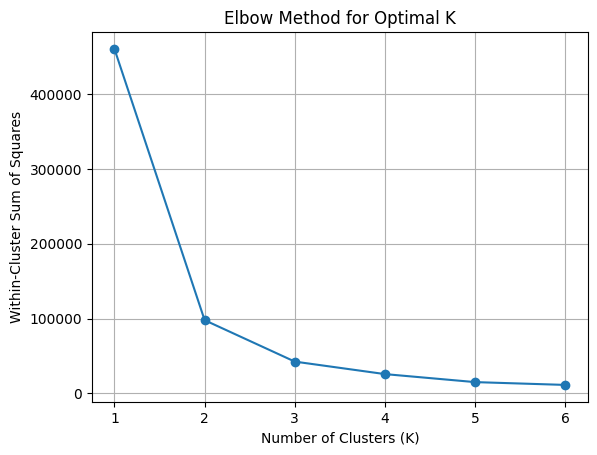

Inertia Values:
K = 1: 460179.0426666667
K = 2: 97907.7838888889
K = 3: 42572.81035714286
K = 4: 25884.355
K = 5: 15191.991666666667
K = 6: 11441.95


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

data = np.array([
    [100, 3.0],
    [120, 3.2],
    [150, 3.5],
    [180, 3.7],
    [200, 4.0],
    [220, 4.1],
    [250, 4.2],
    [300, 4.3],
    [350, 4.5],
    [400, 4.6],
    [450, 4.7],
    [500, 4.8],
    [550, 4.9],
    [600, 4.9],
    [650, 5.0]
])

inertia_values = []

for k in range(1, 7):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(data)
    
    inertia_values.append(kmeans.inertia_)

plt.plot(
    range(1, 7),
    inertia_values,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Within-Cluster Sum of Squares")
plt.title("Elbow Method for Optimal K")
plt.xticks(range(1, 7))
plt.grid()
plt.show()

print("Inertia Values:")
for k, inertia in zip(range(1, 7), inertia_values):
    print(f"K = {k}: {inertia}")